# Quantium Data Analytics Virtual Experience (Forage)

## Task 1: Data Preparation and Customer Analytics

### Business Problem

Quantium has been engaged by a supermarket client to analyze customer purchasing behaviour within the chips category. The objective is to identify purchasing trends, understand customer segments, determine the key drivers of sales, and provide commercial recommendations to support the client's strategic plan for the next six months.

## Project Objectives

This analysis aims to:

- Assess the quality of the transaction and customer datasets.
- Identify and correct data quality issues.
- Engineer additional product features such as brand and pack size.
- Merge transaction and customer datasets for customer-level analysis.
- Explore customer purchasing behaviour and sales drivers.
- Identify high-value customer segments.
- Evaluate brand and pack size performance.
- Provide data-driven commercial recommendations for the client.

## 1. Import Required Libraries


The following libraries are used for data manipulation, feature engineering, data visualization, and exploratory data analysis throughout this project.



In [198]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

# Plot style
plt.style.use("ggplot")

## 2. Load the Datasets

Two datasets are used in this analysis:

- **Transaction Dataset** – Contains retail transaction records including products, quantities purchased, and sales values.
- **Customer Dataset** – Contains customer demographic information such as lifestage and premium customer segment.

These datasets will later be merged using the customer loyalty card number (`LYLTY_CARD_NBR`) to enable customer-level analysis.

In [83]:
transactions=pd.read_csv('QVI_transaction_data.csv') 
customers=pd.read_csv('QVI_purchase_behaviour.csv')

## 3. Initial Data Inspection

The transaction and customer datasets are inspected to understand their structure, identify available variables, verify data types, and detect potential data quality issues before analysis.

In [84]:
transactions.head()


,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
0,43390,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0
1,43599,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3
2,43605,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9
3,43329,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0
4,43330,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8


In [85]:
customers.head()

,LYLTY_CARD_NBR,LIFESTAGE,PREMIUM_CUSTOMER
0,1000,YOUNG SINGLES/COUPLES,Premium
1,1002,YOUNG SINGLES/COUPLES,Mainstream
2,1003,YOUNG FAMILIES,Budget
3,1004,OLDER SINGLES/COUPLES,Mainstream
4,1005,MIDAGE SINGLES/COUPLES,Mainstream


## 4. Data Quality Assessment

Before performing the analysis, both datasets are assessed to identify potential data quality issues that could affect the accuracy of the results.

The assessment includes:

- Dataset dimensions
- Data types
- Summary statistics
- Missing values
- Duplicate records

This step ensures the datasets are complete, consistent, and suitable for further analysis.

# Display information about the transaction dataset

In [86]:
transactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264836 entries, 0 to 264835
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   DATE            264836 non-null  int64  
 1   STORE_NBR       264836 non-null  int64  
 2   LYLTY_CARD_NBR  264836 non-null  int64  
 3   TXN_ID          264836 non-null  int64  
 4   PROD_NBR        264836 non-null  int64  
 5   PROD_NAME       264836 non-null  object 
 6   PROD_QTY        264836 non-null  int64  
 7   TOT_SALES       264836 non-null  float64
dtypes: float64(1), int64(6), object(1)
memory usage: 16.2+ MB


# Display information about the customer dataset

In [87]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72637 entries, 0 to 72636
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   LYLTY_CARD_NBR    72637 non-null  int64 
 1   LIFESTAGE         72637 non-null  object
 2   PREMIUM_CUSTOMER  72637 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB


# Display the shape of both datasets


In [88]:
print("Transaction Dataset Shape:", transactions.shape)
print("Customer Dataset Shape:", customers.shape)

Transaction Dataset Shape: (264836, 8)
Customer Dataset Shape: (72637, 3)


### Duplicate Record Assessment

Duplicate records can lead to biased results and incorrect business insights. Therefore, both datasets are checked for duplicate entries before further analysis.

In [89]:
# Check for duplicate records
print("Duplicate rows in transaction dataset:", transactions.duplicated().sum())

print("Duplicate rows in customer dataset:", customers.duplicated().sum())

Duplicate rows in transaction dataset: 1
Duplicate rows in customer dataset: 0


### Duplicate Record Verification

A duplicate record was detected in the transaction dataset. Before removing it, the duplicate records are inspected to confirm that they are exact duplicates.

In [90]:
# Display duplicate rows
duplicate_rows = transactions[transactions.duplicated()]

duplicate_rows

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
124845,43374,107,107024,108462,45,Smiths Thinly Cut Roast Chicken 175g,2,6.0


# Display all occurrences of duplicate records (original + duplicate)

In [91]:
transactions[transactions.duplicated(keep=False)]

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
124843,43374,107,107024,108462,45,Smiths Thinly Cut Roast Chicken 175g,2,6.0
124845,43374,107,107024,108462,45,Smiths Thinly Cut Roast Chicken 175g,2,6.0


In [92]:
# Remove duplicate records
transactions = transactions.drop_duplicates()

# Verify duplicates have been removed
print("Remaining duplicate rows:", transactions.duplicated().sum())

Remaining duplicate rows: 0


### Missing Value Assessment

Missing values can affect the accuracy of analysis and statistical calculations. Therefore, both datasets are examined to identify any missing values before proceeding with further analysis.

In [93]:
# Check missing values in the transaction dataset
transactions.isnull().sum()

DATE              0
STORE_NBR         0
LYLTY_CARD_NBR    0
TXN_ID            0
PROD_NBR          0
PROD_NAME         0
PROD_QTY          0
TOT_SALES         0
dtype: int64

In [94]:
# Check missing values in the customer dataset
customers.isnull().sum()

LYLTY_CARD_NBR      0
LIFESTAGE           0
PREMIUM_CUSTOMER    0
dtype: int64

### Missing Value Summary

No missing values were identified in either the transaction or customer datasets. Therefore, no additional data imputation or record removal was required before proceeding with the analysis.

### Data Type Assessment

The data types of each variable are reviewed to ensure they are appropriate for analysis. Correct data types are essential for accurate calculations, filtering, and visualization.

In [95]:
transactions.dtypes

DATE                int64
STORE_NBR           int64
LYLTY_CARD_NBR      int64
TXN_ID              int64
PROD_NBR            int64
PROD_NAME          object
PROD_QTY            int64
TOT_SALES         float64
dtype: object

### Initial Findings

The data quality assessment indicates that both datasets are suitable for further analysis.

**Key findings:**

- The transaction dataset contains **264,836** records and **8** variables.
- The customer dataset contains **72,637** records and **3** variables.
- No missing values were identified in either dataset.
- One duplicate transaction record was detected and removed successfully.
- Data types are appropriate for most variables. The `DATE` variable is currently stored as an integer and will be converted to a datetime format during the data cleaning stage.

The datasets are now ready for data cleaning and feature engineering.

## 5. Data Cleaning

The datasets are cleaned to ensure accuracy and consistency before analysis.

The cleaning process includes:

- Converting data types where necessary.
- Identifying and removing invalid transactions.
- Detecting outliers.
- Validating product information.
- Preparing the data for feature engineering and customer analysis.

### 5.1 Date Conversion

The `DATE` variable is stored as an integer representing the number of days since **1899-12-30**. It is converted to the datetime format to enable time-based analysis.

In [96]:
# Convert Excel serial date to datetime format
transactions["DATE"] = pd.to_datetime(
    transactions["DATE"],
    origin="1899-12-30",
    unit="D"
)

# Verify the updated data type
transactions.dtypes

DATE              datetime64[ns]
STORE_NBR                  int64
LYLTY_CARD_NBR             int64
TXN_ID                     int64
PROD_NBR                   int64
PROD_NAME                 object
PROD_QTY                   int64
TOT_SALES                float64
dtype: object

### 5.2 Product Quantity Assessment

The quantity purchased per transaction is examined to identify unusual purchasing behaviour that may indicate data errors or non-retail transactions.

In [97]:
transactions["PROD_QTY"].describe()

count    264835.000000
mean          1.907308
std           0.643655
min           1.000000
25%           2.000000
50%           2.000000
75%           2.000000
max         200.000000
Name: PROD_QTY, dtype: float64

### Observation

The summary statistics indicate that most transactions contain **1–2 packs**, with a median of **2 packs** per transaction.

However, the maximum purchase quantity is **200 packs**, which is substantially higher than the typical transaction size and may represent an outlier or a non-retail purchase.

This transaction will be investigated before determining whether it should be included in the analysis.

### 5.3 Outlier Investigation

A boxplot is used to visualize the distribution of product quantities and identify unusually large purchases that may influence the analysis.

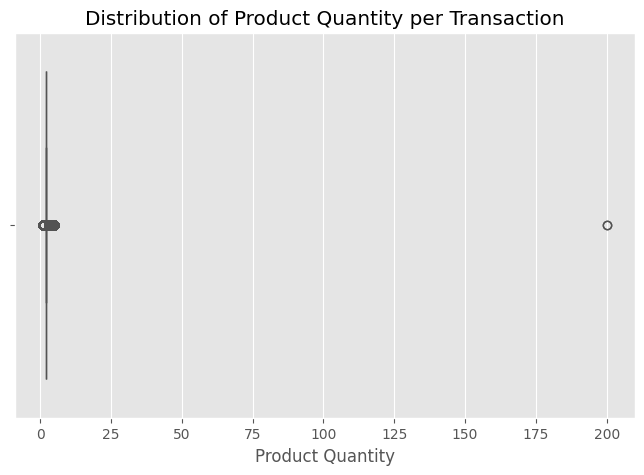

In [98]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=transactions["PROD_QTY"]
)

plt.title("Distribution of Product Quantity per Transaction")
plt.xlabel("Product Quantity")

plt.show()

### Observation

The boxplot confirms the presence of an extreme outlier. While most customers purchase between **1 and 2 packs** per transaction, one transaction contains a substantially larger quantity than the rest of the dataset.

This transaction will be investigated to determine whether it represents a valid retail purchase or a non-retail transaction.

### 5.4 Investigating the Outlier

The unusually large purchase identified in the previous step is investigated to determine whether it represents a genuine retail transaction or a non-retail purchase that could bias the analysis.

In [99]:
# Display transactions with unusually high product quantities
transactions[transactions["PROD_QTY"] == transactions["PROD_QTY"].max()]

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
69762,2018-08-19,226,226000,226201,4,Dorito Corn Chp Supreme 380g,200,650.0
69763,2019-05-20,226,226000,226210,4,Dorito Corn Chp Supreme 380g,200,650.0


In [100]:
# Identify the customer responsible for the large purchase
outlier_customer = transactions.loc[
    transactions["PROD_QTY"] == 200,
    "LYLTY_CARD_NBR"
].iloc[0]

print("Outlier Customer:", outlier_customer)

Outlier Customer: 226000


In [101]:
transactions[
    transactions["LYLTY_CARD_NBR"] == outlier_customer
].sort_values("DATE")

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
69762,2018-08-19,226,226000,226201,4,Dorito Corn Chp Supreme 380g,200,650.0
69763,2019-05-20,226,226000,226210,4,Dorito Corn Chp Supreme 380g,200,650.0


### Business Decision

The investigation shows that customer **226000** made only two transactions, each purchasing **200 packs** of the same product.

Such purchasing behaviour is highly unlikely for a typical supermarket customer and is more consistent with a commercial or wholesale purchase.

Since the objective of this analysis is to understand **retail customer purchasing behaviour**, this customer will be excluded to prevent the analysis from being biased.

In [102]:
# Remove the outlier customer
transactions = transactions[
    transactions["LYLTY_CARD_NBR"] != outlier_customer
]

In [103]:
# Verify the customer has been removed
transactions[
    transactions["LYLTY_CARD_NBR"] == outlier_customer
]

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES


### Observation

The outlier customer was successfully removed from the transaction dataset.

The cleaned dataset now better represents typical retail purchasing behaviour and is suitable for customer analytics.

### 5.5 Product Validation

Since this project focuses on the **chips category**, the product names are examined to identify any items that do not belong to this category.

Products that are incorrectly classified as chips are removed to ensure the analysis reflects only relevant chip purchases.

In [104]:
# Identify products containing "salsa"
transactions[transactions["PROD_NAME"].str.contains("salsa", case=False, na=False)]["PROD_NAME"].unique()

array(['Old El Paso Salsa   Dip Tomato Mild 300g',
       'Red Rock Deli SR    Salsa & Mzzrlla 150g',
       'Smiths Crinkle Cut  Tomato Salsa 150g',
       'Doritos Salsa       Medium 300g',
       'Old El Paso Salsa   Dip Chnky Tom Ht300g',
       'Woolworths Mild     Salsa 300g',
       'Old El Paso Salsa   Dip Tomato Med 300g',
       'Woolworths Medium   Salsa 300g', 'Doritos Salsa Mild  300g'],
      dtype=object)

In [105]:
# Count each salsa-related product
transactions[
    transactions["PROD_NAME"].str.contains("Salsa", case=False, na=False)
]["PROD_NAME"].value_counts()

PROD_NAME
Old El Paso Salsa   Dip Chnky Tom Ht300g    3125
Old El Paso Salsa   Dip Tomato Med 300g     3114
Old El Paso Salsa   Dip Tomato Mild 300g    3085
Woolworths Mild     Salsa 300g              1491
Doritos Salsa Mild  300g                    1472
Smiths Crinkle Cut  Tomato Salsa 150g       1470
Red Rock Deli SR    Salsa & Mzzrlla 150g    1458
Doritos Salsa       Medium 300g             1449
Woolworths Medium   Salsa 300g              1430
Name: count, dtype: int64

In [106]:
# Remove only salsa dip products
salsa_products = [
    "Old El Paso Salsa   Dip Chnky Tom Ht300g",
    "Old El Paso Salsa   Dip Tomato Med 300g",
    "Old El Paso Salsa   Dip Tomato Mild 300g",
    "Woolworths Mild     Salsa 300g",
    "Woolworths Medium   Salsa 300g",
    "Doritos Salsa Mild  300g",
    "Doritos Salsa       Medium 300g"
]

transactions = transactions[
    ~transactions["PROD_NAME"].isin(salsa_products)
]

In [107]:
# Verify remaining salsa-related products
transactions[
    transactions["PROD_NAME"].str.contains("Salsa", case=False, na=False)
]["PROD_NAME"].value_counts()

PROD_NAME
Smiths Crinkle Cut  Tomato Salsa 150g       1470
Red Rock Deli SR    Salsa & Mzzrlla 150g    1458
Name: count, dtype: int64

### Observation

Nine products containing the word **"Salsa"** were identified. A detailed review showed that **seven** were salsa dips, while **two** were salsa-flavoured chip products.

To maintain the focus on the chips category, only the salsa dip products were removed. Salsa-flavoured chips were retained because they are valid chip products and form part of the client's category of interest.

The cleaned dataset now contains only relevant chip products and is ready for feature engineering.

## 6. Feature Engineering

To support customer purchasing behaviour analysis, additional product attributes are extracted from the product description.

The following features are engineered:

- **Pack Size** – extracted from the product name.
- **Brand Name** – extracted and standardized from the product name.

These variables will be used to analyze customer preferences, sales performance, and purchasing trends.

### 6.1 Extracting Pack Size

Pack size is extracted from the product description using regular expressions. This feature enables analysis of customer preferences across different product sizes.

In [108]:
# Extract pack size (grams)
import re
transactions["PACK_SIZE"] = (
    transactions["PROD_NAME"]
    .str.extract(r'(\d+)g', flags=re.IGNORECASE)[0]
    .astype(int)
)

In [109]:
transactions[["PROD_NAME", "PACK_SIZE"]].head()

,PROD_NAME,PACK_SIZE
0,Natural Chip Compny SeaSalt175g,175
1,CCs Nacho Cheese 175g,175
2,Smiths Crinkle Cut Chips Chicken 170g,170
3,Smiths Chip Thinly S/Cream&Onion 175g,175
4,Kettle Tortilla ChpsHny&Jlpno Chili 150g,150


### 6.2 Extracting Brand Name

The brand name is extracted from the beginning of each product description. This feature will be standardized later to ensure consistent brand names across the dataset.

In [110]:
# Extract brand names from the product description
transactions['BRAND'] = transactions['PROD_NAME'].str.split().str[0]

In [111]:
transactions[['PROD_NAME', 'BRAND']].head()

,PROD_NAME,BRAND
0,Natural Chip Compny SeaSalt175g,Natural
1,CCs Nacho Cheese 175g,CCs
2,Smiths Crinkle Cut Chips Chicken 170g,Smiths
3,Smiths Chip Thinly S/Cream&Onion 175g,Smiths
4,Kettle Tortilla ChpsHny&Jlpno Chili 150g,Kettle


### Observation

The initial brand names were successfully extracted from the product descriptions.

Some brands may appear under abbreviated or inconsistent names (for example, "Red" instead of "Red Rock Deli"). These inconsistencies will be corrected during the brand standardization step.

### 6.3 Brand Standardization

Some product brands appear with inconsistent or abbreviated names. To improve analysis accuracy, these brands are standardized so that products from the same brand are grouped together.

This ensures that sales and customer insights are calculated correctly at the brand level.

In [112]:
# Display all unique brand names
sorted(transactions["BRAND"].unique())

['Burger',
 'CCs',
 'Cheetos',
 'Cheezels',
 'Cobs',
 'Dorito',
 'Doritos',
 'French',
 'Grain',
 'GrnWves',
 'Infuzions',
 'Infzns',
 'Kettle',
 'NCC',
 'Natural',
 'Pringles',
 'RRD',
 'Red',
 'Smith',
 'Smiths',
 'Snbts',
 'Sunbites',
 'Thins',
 'Tostitos',
 'Twisties',
 'Tyrrells',
 'WW',
 'Woolworths']

In [113]:
# Standardize brand names
transactions["BRAND"] = transactions["BRAND"].replace({
    "Dorito": "Doritos",
    "Infzns": "Infuzions",
    "Smith": "Smiths",
    "RRD": "Red Rock Deli",
    "Red": "Red Rock Deli",
    "NCC": "Natural Chip Co",
    "Natural": "Natural Chip Co",
    "Grain": "Grain Waves",
    "GrnWves": "Grain Waves",
    "Snbts": "Sunbites",
    "WW": "Woolworths",
    "Burger": "Burger Rings",
    "French": "French Fries"
})

In [114]:
# Display all unique brand names
len(sorted(transactions["BRAND"].unique()))

20

In [115]:
# Verify standardized brand names
transactions.head(10)

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PACK_SIZE,BRAND
0,2018-10-17,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0,175,Natural Chip Co
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3,175,CCs
2,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9,170,Smiths
3,2018-08-17,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0,175,Smiths
4,2018-08-18,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8,150,Kettle
6,2019-05-16,4,4149,3333,16,Smiths Crinkle Chips Salt & Vinegar 330g,1,5.7,330,Smiths
7,2019-05-16,4,4196,3539,24,Grain Waves Sweet Chilli 210g,1,3.6,210,Grain Waves
8,2018-08-20,5,5026,4525,42,Doritos Corn Chip Mexican Jalapeno 150g,1,3.9,150,Doritos
9,2018-08-18,7,7150,6900,52,Grain Waves Sour Cream&Chives 210G,2,7.2,210,Grain Waves
10,2019-05-17,7,7215,7176,16,Smiths Crinkle Chips Salt & Vinegar 330g,1,5.7,330,Smiths


### Observation

The extracted brand names contained several abbreviations and inconsistent naming conventions.

These values were standardized into **20 unique brands**, ensuring that products from the same manufacturer are grouped together correctly.

This improves the accuracy of brand-level sales analysis and customer purchasing behaviour insights.

# 7. Exploratory Data Analysis

To analyze customer purchasing behaviour, the cleaned transaction data is merged with the customer dataset using the loyalty card number.

This creates a single dataset containing both transaction details and customer demographic information, enabling customer segmentation and sales analysis.

## 7.1 Merge transaction and customer datasets

In [116]:
# Merge transaction and customer datasets
merged_data = transactions.merge(
    customers,
    on="LYLTY_CARD_NBR",
    how="left"
)

In [117]:
# Display dataset dimensions
merged_data.shape

(249667, 12)

In [118]:
# Preview merged dataset
merged_data.head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PACK_SIZE,BRAND,LIFESTAGE,PREMIUM_CUSTOMER
0,2018-10-17,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0,175,Natural Chip Co,YOUNG SINGLES/COUPLES,Premium
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3,175,CCs,MIDAGE SINGLES/COUPLES,Budget
2,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9,170,Smiths,MIDAGE SINGLES/COUPLES,Budget
3,2018-08-17,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0,175,Smiths,MIDAGE SINGLES/COUPLES,Budget
4,2018-08-18,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8,150,Kettle,MIDAGE SINGLES/COUPLES,Budget


### Observation

The transaction and customer datasets were successfully merged using the loyalty card number.

The merged dataset contains **249,667 transactions** and **12 variables**, combining transaction information with customer demographic attributes.

This integrated dataset provides the foundation for customer segmentation, purchasing behaviour analysis, and business insight generation.

## 7.2 Business Overview

Before performing detailed customer and product analysis, key business performance indicators (KPIs) are calculated to provide an overview of the chips category.

The following metrics are examined:

- Total Sales Revenue
- Total Transactions
- Total Unique Customers
- Average Transaction Value

These KPIs provide a high-level summary of overall business performance before exploring customer purchasing behaviour.

In [119]:
# Calculate key business metrics
total_sales = merged_data["TOT_SALES"].sum()

total_transactions = merged_data["TXN_ID"].nunique()

total_customers = merged_data["LYLTY_CARD_NBR"].nunique()

average_transaction_value = (
    merged_data["TOT_SALES"].sum()
    / merged_data["TXN_ID"].nunique()
)

print(f"Total Sales Revenue: ${total_sales:,.2f}")
print(f"Total Transactions: {total_transactions:,}")
print(f"Total Customers: {total_customers:,}")
print(f"Average Transaction Value: ${average_transaction_value:.2f}")

Total Sales Revenue: $1,819,778.40
Total Transactions: 248,156
Total Customers: 71,517
Average Transaction Value: $7.33


### Observation

The business overview indicates strong customer activity within the chips category.

After data cleaning, the dataset contains **248,156 transactions** completed by **71,517 unique customers**, generating **$1,819,778.40** in total sales revenue.

The average transaction value is **$7.33**, providing a useful baseline for evaluating customer purchasing behaviour, product preferences, and sales drivers in the following analyses.

## 7.3 Monthly Sales Trend

Monthly sales revenue is analyzed to understand how sales change over time.

This analysis helps identify overall sales trends, seasonal patterns, and months with unusually high or low revenue. Understanding these trends supports better business planning and inventory management.

In [120]:
# Create Year-Month column
merged_data["YEAR_MONTH"] = merged_data["DATE"].dt.to_period("M")

# Calculate monthly sales revenue
monthly_sales = (
    merged_data
    .groupby("YEAR_MONTH")["TOT_SALES"]
    .sum()
    .reset_index()
)

# Convert period to string for plotting
monthly_sales["YEAR_MONTH"] = monthly_sales["YEAR_MONTH"].astype(str)

monthly_sales.head(18)

,YEAR_MONTH,TOT_SALES
0,2018-07,155766.70
1,2018-08,148464.85
2,2018-09,151153.70
3,2018-10,154581.50
4,2018-11,150878.30
5,2018-12,157820.10
6,2019-01,152832.40
7,2019-02,141600.30
8,2019-03,157116.00
9,2019-04,150601.00


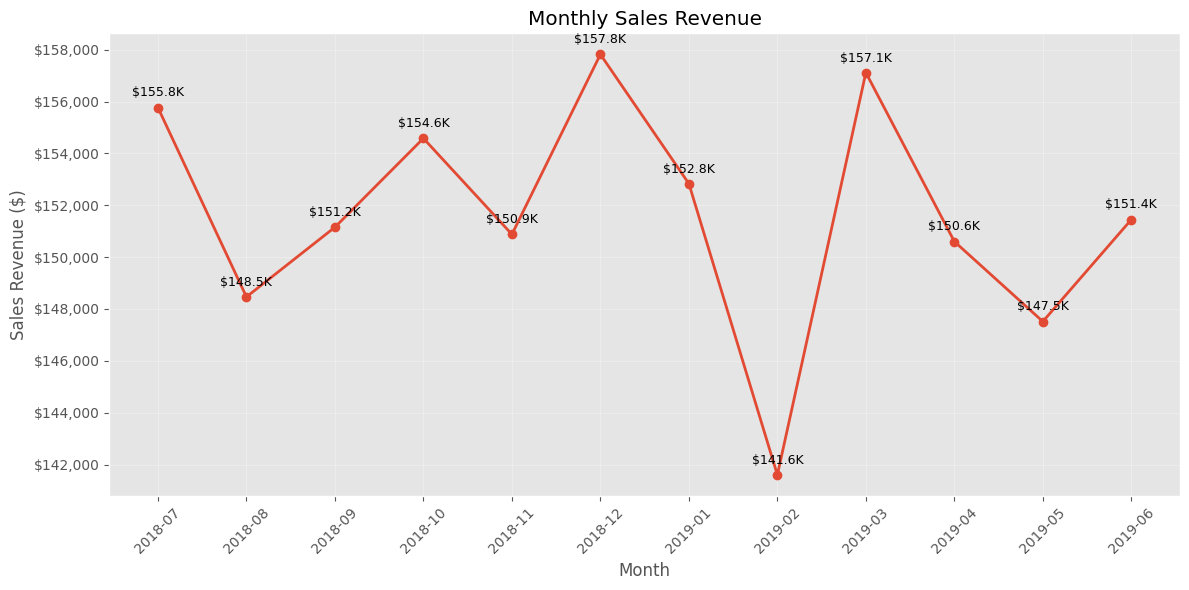

In [121]:
from matplotlib.ticker import StrMethodFormatter

plt.figure(figsize=(12,6))

plt.plot(
    monthly_sales["YEAR_MONTH"].astype(str),
    monthly_sales["TOT_SALES"],
    marker="o",
    linewidth=2
)

plt.title("Monthly Sales Revenue")
plt.xlabel("Month")
plt.ylabel("Sales Revenue ($)")

plt.xticks(rotation=45)

# Format y-axis
plt.gca().yaxis.set_major_formatter(StrMethodFormatter('${x:,.0f}'))

# Add values above points
for x, y in zip(monthly_sales["YEAR_MONTH"].astype(str),
                monthly_sales["TOT_SALES"]):
    plt.annotate(
        f"${y/1000:.1f}K",
        (x, y),
        textcoords="offset points",
        xytext=(0, 8),
        ha="center",
        fontsize=9
    )

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "monthly_sales_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

Monthly sales revenue remained relatively stable throughout the analysis period, with sales generally ranging between **$148,000** and **$158,000** per month.

The highest sales were recorded in **December 2018**, likely reflecting increased holiday season demand. In contrast, **February 2019** recorded the lowest monthly sales, which is expected due to the shorter month.

Overall, the sales trend indicates consistent customer demand for chip products with only moderate month-to-month variation.

## 7.4 Sales by Customer Lifestage

Customer lifestage is analyzed to identify which customer groups contribute the highest sales revenue.

Understanding sales performance across different lifestages helps identify valuable customer segments and supports targeted marketing strategies.

In [122]:
# Calculate total sales by customer lifestage
lifestage_sales = (
    merged_data
    .groupby("LIFESTAGE")["TOT_SALES"]
    .sum()
    .sort_values(ascending=False)
)

lifestage_sales

LIFESTAGE
OLDER SINGLES/COUPLES     378877.95
RETIREES                  344886.90
OLDER FAMILIES            331643.80
YOUNG FAMILIES            297396.00
YOUNG SINGLES/COUPLES     245307.50
MIDAGE SINGLES/COUPLES    174010.50
NEW FAMILIES               47655.75
Name: TOT_SALES, dtype: float64

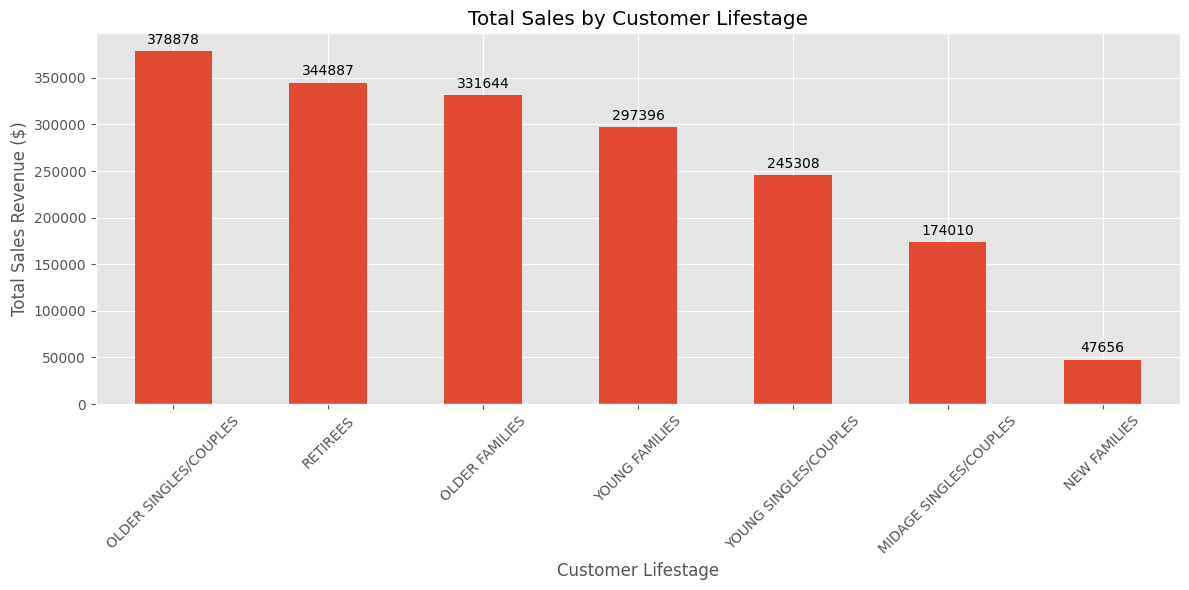

In [123]:

plt.figure(figsize=(12,6))

ax = lifestage_sales.plot(kind="bar")

plt.title("Total Sales by Customer Lifestage")
plt.xlabel("Customer Lifestage")
plt.ylabel("Total Sales Revenue ($)")
plt.xticks(rotation=45)

# Add values on top of each bar
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=3)

plt.tight_layout()
plt.savefig("customer_lifestage_sales.png", dpi=300, bbox_inches="tight")
plt.show()

### Observation

Customer lifestage analysis shows that **Older Singles/Couples** generated the highest sales revenue at **$378,877.95**, followed by **Retirees** with **$344,886.90** and **Older Families** with **$331,643.80**.

These results indicate that older customer segments are the largest contributors to chip category sales.

In comparison, **New Families** generated the lowest sales revenue at **$47,655.75**, suggesting that this segment currently has lower purchasing activity within the chips category.

The findings suggest that marketing strategies could focus on high-value older customer segments while exploring opportunities to increase engagement among lower-performing segments.

## 7.5 Sales by Premium Customer Segment

Customer purchasing behaviour is further analyzed based on the **Premium Customer** classification.

This analysis compares total sales generated by **Budget**, **Mainstream**, and **Premium** customers to identify which customer segment contributes the most revenue to the chips category.

In [124]:
# Calculate total sales by premium customer segment
premium_sales = (
    merged_data
    .groupby("PREMIUM_CUSTOMER")["TOT_SALES"]
    .sum()
    .sort_values(ascending=False)
)

premium_sales

PREMIUM_CUSTOMER
Mainstream    706252.50
Budget        636632.85
Premium       476893.05
Name: TOT_SALES, dtype: float64

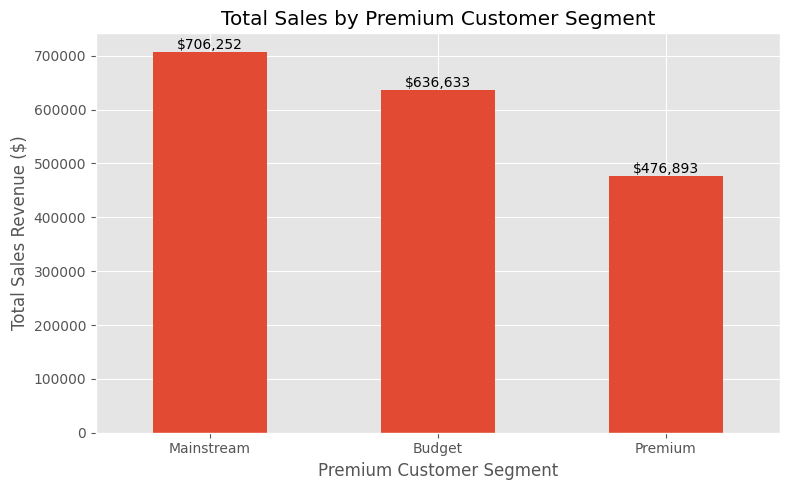

In [125]:


plt.figure(figsize=(8,5))

ax = premium_sales.plot(kind="bar")

plt.title("Total Sales by Premium Customer Segment")
plt.xlabel("Premium Customer Segment")
plt.ylabel("Total Sales Revenue ($)")
plt.xticks(rotation=0)

# Add values on top of each bar
for bar in ax.patches:
    ax.annotate(
        f'${bar.get_height():,.0f}',
        (bar.get_x() + bar.get_width() / 2, bar.get_height()),
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.tight_layout()
plt.savefig("premium_customer_sales.png", dpi=300, bbox_inches="tight")


plt.show()

### Observation

Sales analysis by customer segment shows that **Mainstream customers** generated the highest sales revenue at **$706,252.50**, followed by **Budget customers** with **$636,632.85**.


**Premium customers** contributed **$476,893.05**, representing the smallest share of total sales among the three customer segments.
    

These findings indicate that the chips category is primarily driven by Mainstream and Budget customers, suggesting that promotions and marketing campaigns targeting these segments may have the greatest impact on overall sales performance.

## 7.6 Sales by Brand

Brand-level sales analysis is performed to identify the brands that contribute the highest revenue within the chips category.

Understanding brand performance helps identify market leaders, customer preferences, and opportunities for business growth.

In [126]:
# Calculate total sales by brand
brand_sales = (
    merged_data
    .groupby("BRAND")["TOT_SALES"]
    .sum()
    .sort_values(ascending=False)
)

brand_sales

BRAND
Kettle             390239.8
Doritos            226329.9
Smiths             224654.2
Pringles           177655.5
Infuzions           99047.6
Red Rock Deli       95046.0
Thins               88852.5
Twisties            81522.1
Tostitos            79789.6
Cobs                70569.8
Tyrrells            51647.4
Grain Waves         51617.2
Natural Chip Co     42318.0
Woolworths          41059.1
Cheezels            40029.9
CCs                 18078.9
Cheetos             16884.5
Sunbites             9676.4
French Fries         7929.0
Burger Rings         6831.0
Name: TOT_SALES, dtype: float64

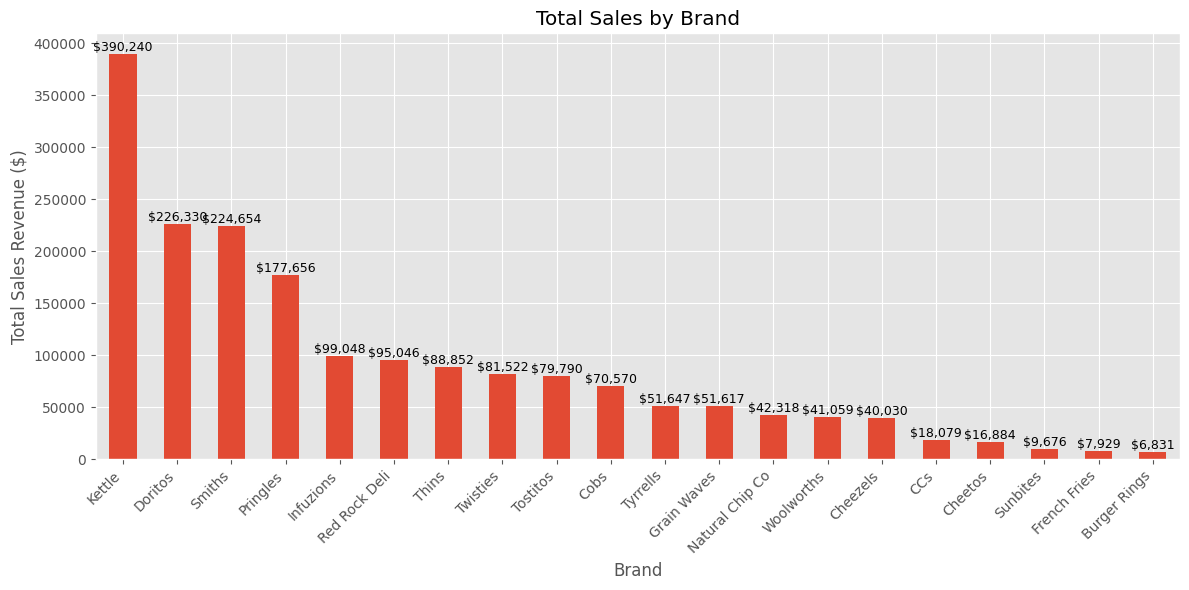

In [127]:


plt.figure(figsize=(12,6))

ax = brand_sales.plot(kind="bar")

plt.title("Total Sales by Brand")
plt.xlabel("Brand")
plt.ylabel("Total Sales Revenue ($)")
plt.xticks(rotation=45, ha="right")

# Add value labels
for bar in ax.patches:
    ax.annotate(
        f'${bar.get_height():,.0f}',
        (bar.get_x() + bar.get_width()/2, bar.get_height()),
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.tight_layout()
plt.savefig(
    "brand_performance.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### Observation

Brand-level sales analysis shows that **Kettle** is the market leader, generating **$390,239.80** in total sales, significantly outperforming all other brands.

**Doritos** ($226,329.90) and **Smiths** ($224,654.20) are the second and third highest-performing brands, followed by **Pringles** ($177,655.50).

Brands such as **Burger Rings**, **French Fries**, and **Sunbites** generated comparatively lower sales, indicating a smaller market presence within the chips category.

These findings suggest that Kettle, Doritos, Smiths, and Pringles are the primary revenue drivers and should remain key focus brands for merchandising, promotions, and inventory planning.

## 7.7 Sales by Pack Size

Pack size analysis is performed to identify which product sizes generate the highest sales revenue.

Understanding customer preferences for different pack sizes helps support product assortment decisions, inventory planning, and promotional strategies.

In [128]:
# Calculate total sales by pack size
pack_size_sales = (
    merged_data
    .groupby("PACK_SIZE")["TOT_SALES"]
    .sum()
    .sort_values(ascending=False)
)

pack_size_sales

PACK_SIZE
175    485431.4
150    304288.5
134    177655.5
110    162765.4
170    146673.0
330    136794.3
165    101360.6
380     75419.6
270     55425.4
210     43048.8
250     26096.7
135     26090.4
200     16007.5
190     14412.9
160     10647.6
90       9676.4
180      8568.4
70       6852.0
220      6831.0
125      5733.0
Name: TOT_SALES, dtype: float64

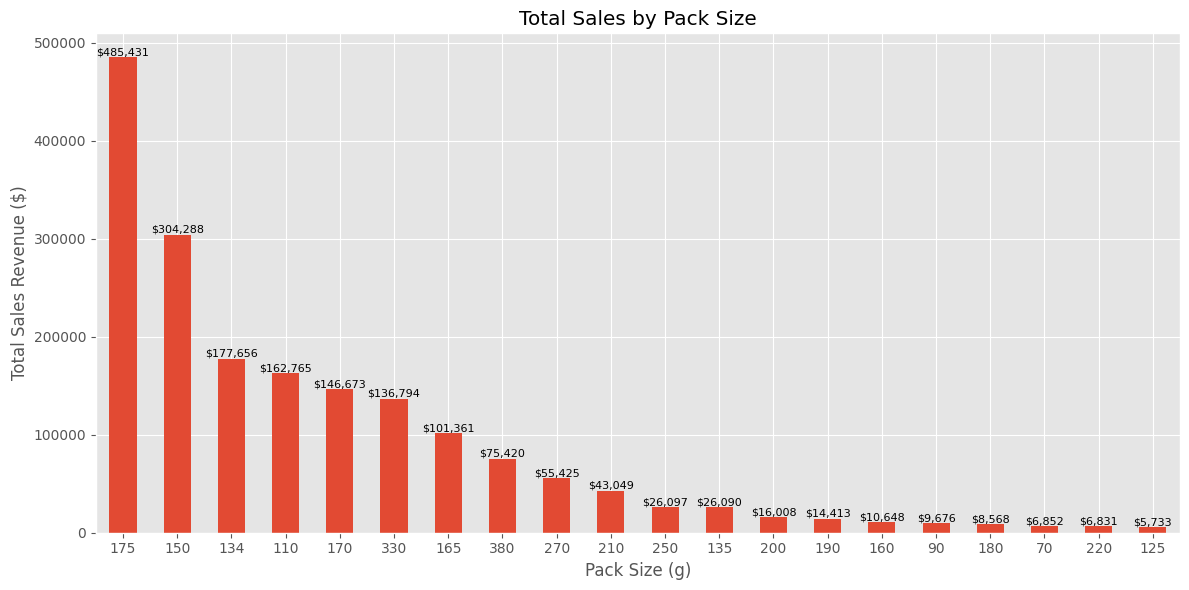

In [129]:


plt.figure(figsize=(12,6))

ax = pack_size_sales.plot(kind="bar")

plt.title("Total Sales by Pack Size")
plt.xlabel("Pack Size (g)")
plt.ylabel("Total Sales Revenue ($)")
plt.xticks(rotation=0)

# Add value labels
for bar in ax.patches:
    ax.annotate(
        f'${bar.get_height():,.0f}',
        (bar.get_x() + bar.get_width()/2, bar.get_height()),
        ha='center',
        va='bottom',
        fontsize=8
    )

plt.tight_layout()
plt.savefig(
    "pack_size_performance.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### Observation

Pack size analysis shows that **175g** packs generated the highest sales revenue at **$485,431.40**, making them the most popular pack size among customers.

The **150g** pack ranked second with **$304,288.50**, followed by **134g**, **110g**, and **170g** packs.

Larger pack sizes such as **330g** and **380g** also contributed meaningful sales, while smaller pack sizes including **70g**, **90g**, and **125g** generated comparatively lower revenue.

These findings indicate that customers primarily prefer medium-sized chip packs, suggesting that these pack sizes should remain a key focus for product assortment, inventory management, and promotional activities.

## 7.8 Customer Segment Analysis

Customer purchasing behaviour is analyzed by combining **Lifestage** and **Premium Customer** segments.

This analysis identifies which customer groups contribute the highest sales revenue and provides insights into the most valuable customer segments for the chips category.

The findings support targeted marketing strategies and commercial recommendations.

In [130]:
# Calculate total sales by customer segment
customer_segment_sales = (
    merged_data
    .groupby(["LIFESTAGE", "PREMIUM_CUSTOMER"])["TOT_SALES"]
    .sum()
    .sort_values(ascending=False)
)

customer_segment_sales

LIFESTAGE               PREMIUM_CUSTOMER
OLDER FAMILIES          Budget              158379.95
YOUNG SINGLES/COUPLES   Mainstream          148337.20
RETIREES                Mainstream          146328.75
YOUNG FAMILIES          Budget              130919.05
OLDER SINGLES/COUPLES   Budget              128683.80
                        Mainstream          125737.10
                        Premium             124457.05
RETIREES                Budget              106606.20
OLDER FAMILIES          Mainstream           97280.85
RETIREES                Premium              91951.95
YOUNG FAMILIES          Mainstream           87227.85
MIDAGE SINGLES/COUPLES  Mainstream           85262.75
YOUNG FAMILIES          Premium              79249.10
OLDER FAMILIES          Premium              75983.00
YOUNG SINGLES/COUPLES   Budget               57622.40
MIDAGE SINGLES/COUPLES  Premium              55042.35
YOUNG SINGLES/COUPLES   Premium              39347.90
MIDAGE SINGLES/COUPLES  Budget           

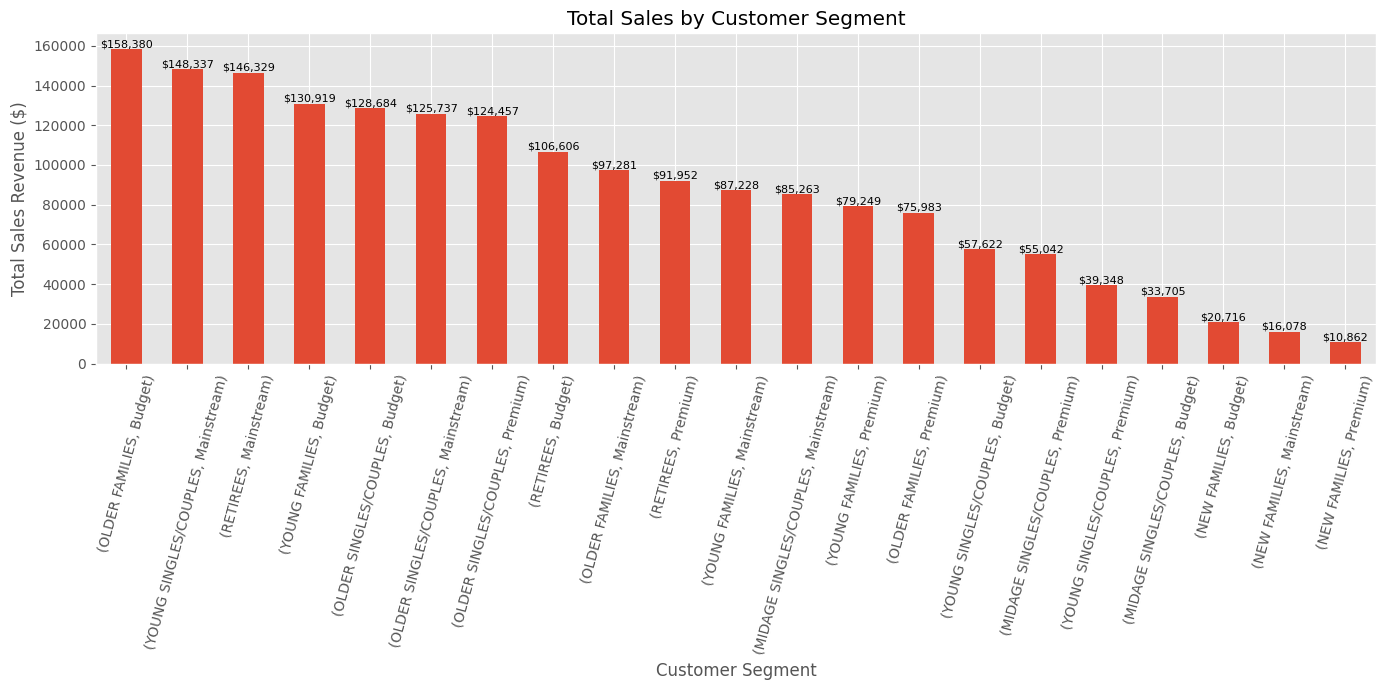

In [131]:


plt.figure(figsize=(14,7))

ax = customer_segment_sales.plot(kind="bar")

plt.title("Total Sales by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Total Sales Revenue ($)")
plt.xticks(rotation=75)

# Add value labels
for bar in ax.patches:
    ax.annotate(
        f'${bar.get_height():,.0f}',
        (bar.get_x() + bar.get_width()/2, bar.get_height()),
        ha='center',
        va='bottom',
        fontsize=8
    )

plt.tight_layout()
plt.savefig("Total_Sales_by_Customer_Segment.png", dpi=300, bbox_inches="tight")

plt.show()

### Observation

Customer segment analysis reveals that **Budget Older Families** generated the highest sales revenue at **$158,379.95**, making them the most valuable customer segment for the chips category.

The next highest-performing segments were **Mainstream Young Singles/Couples** (**$148,337.20**) and **Mainstream Retirees** (**$146,328.75**).

In contrast, **Premium New Families** generated the lowest sales revenue (**$10,861.70**), indicating a relatively small contribution to overall category sales.

These findings suggest that customer purchasing behaviour differs across demographic and spending segments. High-performing segments such as Budget Older Families and Mainstream Young Singles/Couples represent valuable target groups for future marketing campaigns and promotional activities.

## 7.9 Number of Customers by Customer Segment

The number of unique customers is calculated for each customer segment to understand which groups contribute the largest customer base.

This analysis helps distinguish whether high sales are driven by a larger number of customers or by higher spending behaviour.

In [132]:
# Number of unique customers by segment
customer_count = (
    merged_data
    .groupby(["LIFESTAGE", "PREMIUM_CUSTOMER"])["LYLTY_CARD_NBR"]
    .nunique()
    .sort_values(ascending=False)
)

customer_count

LIFESTAGE               PREMIUM_CUSTOMER
YOUNG SINGLES/COUPLES   Mainstream          7930
RETIREES                Mainstream          6382
OLDER SINGLES/COUPLES   Mainstream          4870
                        Budget              4864
                        Premium             4694
OLDER FAMILIES          Budget              4622
RETIREES                Budget              4396
YOUNG FAMILIES          Budget              3961
RETIREES                Premium             3821
YOUNG SINGLES/COUPLES   Budget              3675
MIDAGE SINGLES/COUPLES  Mainstream          3302
OLDER FAMILIES          Mainstream          2796
YOUNG FAMILIES          Mainstream          2693
YOUNG SINGLES/COUPLES   Premium             2499
YOUNG FAMILIES          Premium             2404
MIDAGE SINGLES/COUPLES  Premium             2381
OLDER FAMILIES          Premium             2240
MIDAGE SINGLES/COUPLES  Budget              1484
NEW FAMILIES            Budget              1092
                        Main

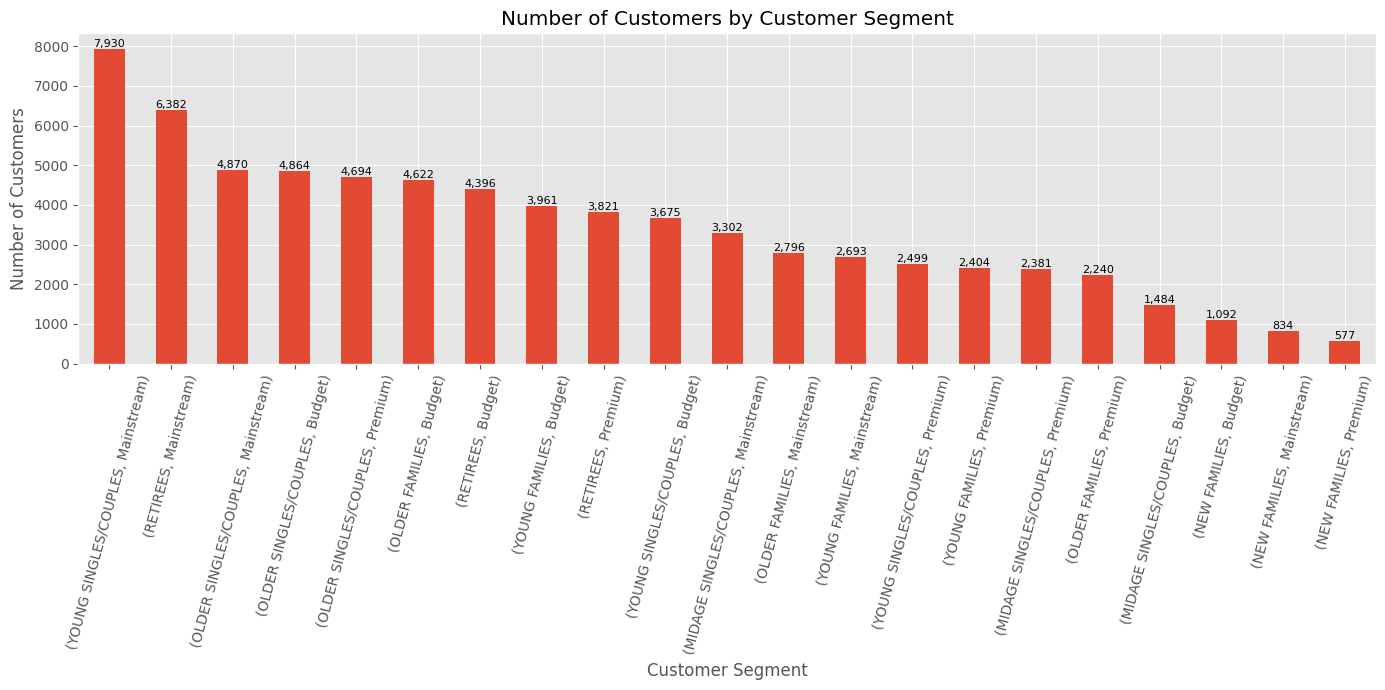

In [133]:


plt.figure(figsize=(14,7))

ax = customer_count.plot(kind="bar")

plt.title("Number of Customers by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=75)

# Value labels
for bar in ax.patches:
    ax.annotate(
        f'{int(bar.get_height()):,}',
        (bar.get_x() + bar.get_width()/2, bar.get_height()),
        ha='center',
        va='bottom',
        fontsize=8
    )

plt.tight_layout()

plt.show()

### Observation

The largest customer segment is **Mainstream Young Singles/Couples**, with **7,930 unique customers**, followed by **Mainstream Retirees** (**6,382 customers**).

Although **Budget Older Families** generated the highest sales revenue, they do not represent the largest customer group. This suggests that their higher sales are driven by stronger purchasing behaviour rather than simply having more customers.

The smallest customer segment is **Premium New Families**, with **577 customers**, indicating a relatively limited contribution to the overall customer base.

## 7.10 Average Chips Purchased per Customer

The average number of chip packets purchased per customer is calculated for each customer segment.

This metric helps identify customer groups that purchase larger quantities of products and provides insight into purchasing behaviour beyond total sales.

In [134]:
# Average chip packets purchased per customer
avg_units = (
    merged_data
    .groupby(["LIFESTAGE", "PREMIUM_CUSTOMER"])[["PROD_QTY", "LYLTY_CARD_NBR"]]
    .apply(lambda x: x["PROD_QTY"].sum() / x["LYLTY_CARD_NBR"].nunique())
    .sort_values(ascending=False)
)

avg_units

LIFESTAGE               PREMIUM_CUSTOMER
OLDER FAMILIES          Mainstream          9.346209
                        Budget              9.178927
                        Premium             9.159821
YOUNG FAMILIES          Budget              8.819995
                        Premium             8.800333
                        Mainstream          8.737468
OLDER SINGLES/COUPLES   Budget              6.826480
                        Premium             6.826161
                        Mainstream          6.779877
MIDAGE SINGLES/COUPLES  Mainstream          6.484858
RETIREES                Budget              6.185623
                        Premium             6.153625
MIDAGE SINGLES/COUPLES  Premium             6.142797
                        Budget              6.077493
RETIREES                Mainstream          5.972109
NEW FAMILIES            Mainstream          4.912470
                        Premium             4.864818
                        Budget              4.836996
YOUNG

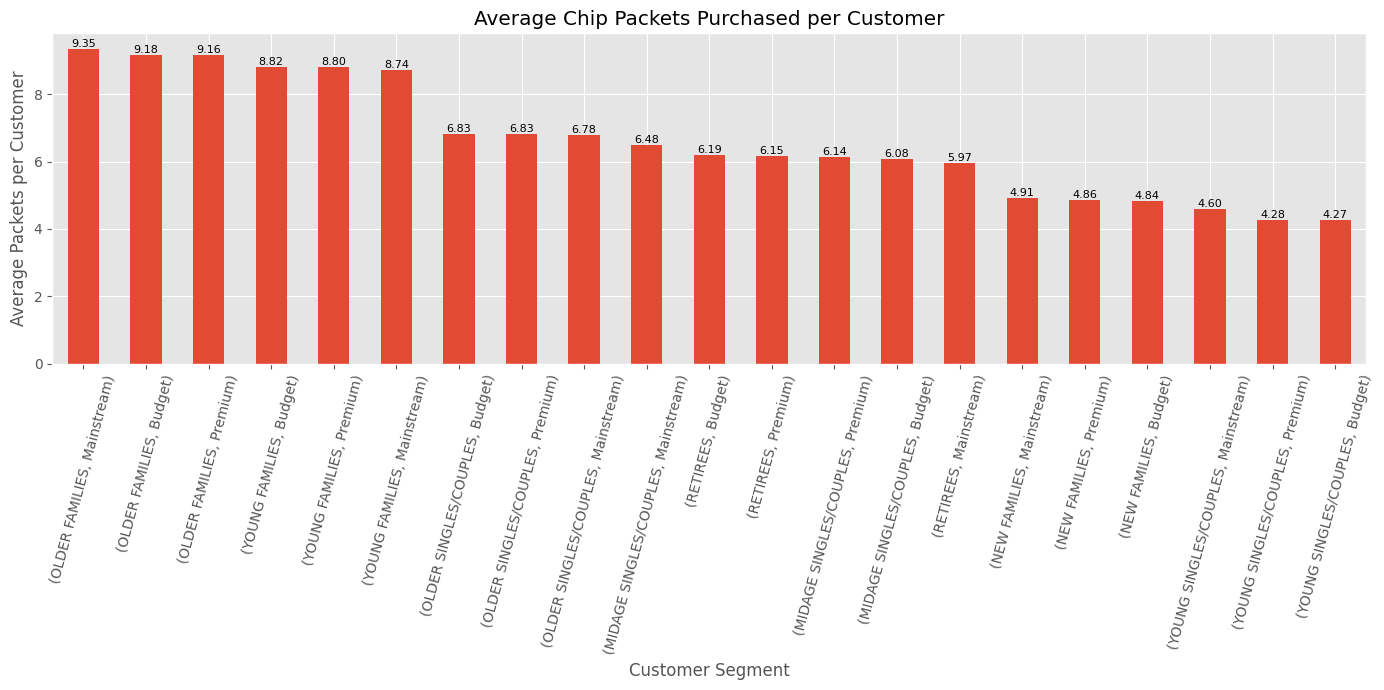

In [135]:
plt.figure(figsize=(14,7))

ax = avg_units.plot(kind="bar")

plt.title("Average Chip Packets Purchased per Customer")
plt.xlabel("Customer Segment")
plt.ylabel("Average Packets per Customer")
plt.xticks(rotation=75)

# Add value labels
for bar in ax.patches:
    ax.annotate(
        f'{bar.get_height():.2f}',
        (bar.get_x() + bar.get_width()/2, bar.get_height()),
        ha='center',
        va='bottom',
        fontsize=8
    )

plt.tight_layout()

plt.show()

### Observation

The analysis shows that **Older Families** purchase the highest number of chip packets per customer across all premium segments, averaging approximately **9 packets per customer**.

**Young Families** also purchase a relatively high number of chip packets, averaging around **8.7 to 8.8 packets per customer**.

In contrast, **Young Singles/Couples** purchase the fewest chip packets per customer, with averages ranging from **4.27 to 4.60 packets**.

These findings suggest that family households tend to purchase chips in larger quantities, while younger single customers buy fewer packets per shopping cycle.

## 7.11 Average Price per Unit by Customer Segment

The average price paid per chip packet is calculated for each customer segment.

This analysis helps identify whether certain customer groups prefer premium-priced products or tend to purchase lower-priced options, providing additional insight into customer purchasing behaviour.

In [136]:
# Calculate average price per unit by customer segment
price_summary = (
    merged_data
    .groupby(["LIFESTAGE", "PREMIUM_CUSTOMER"])
    .agg(
        Total_Sales=("TOT_SALES", "sum"),
        Total_Units=("PROD_QTY", "sum")
    )
)

price_summary["Avg_Price_Per_Unit"] = (
    price_summary["Total_Sales"] / price_summary["Total_Units"]
)

avg_price = price_summary["Avg_Price_Per_Unit"].sort_values(ascending=False)

avg_price

LIFESTAGE               PREMIUM_CUSTOMER
YOUNG SINGLES/COUPLES   Mainstream          4.063031
MIDAGE SINGLES/COUPLES  Mainstream          3.981822
NEW FAMILIES            Mainstream          3.924335
                        Budget              3.922009
RETIREES                Budget              3.920499
                        Premium             3.910686
OLDER SINGLES/COUPLES   Premium             3.884185
                        Budget              3.875551
NEW FAMILIES            Premium             3.869505
RETIREES                Mainstream          3.839239
OLDER SINGLES/COUPLES   Mainstream          3.808138
MIDAGE SINGLES/COUPLES  Premium             3.763322
YOUNG FAMILIES          Budget              3.747397
                        Premium             3.745940
MIDAGE SINGLES/COUPLES  Budget              3.737155
OLDER FAMILIES          Budget              3.733175
                        Mainstream          3.722671
YOUNG FAMILIES          Mainstream          3.707091
OLDER

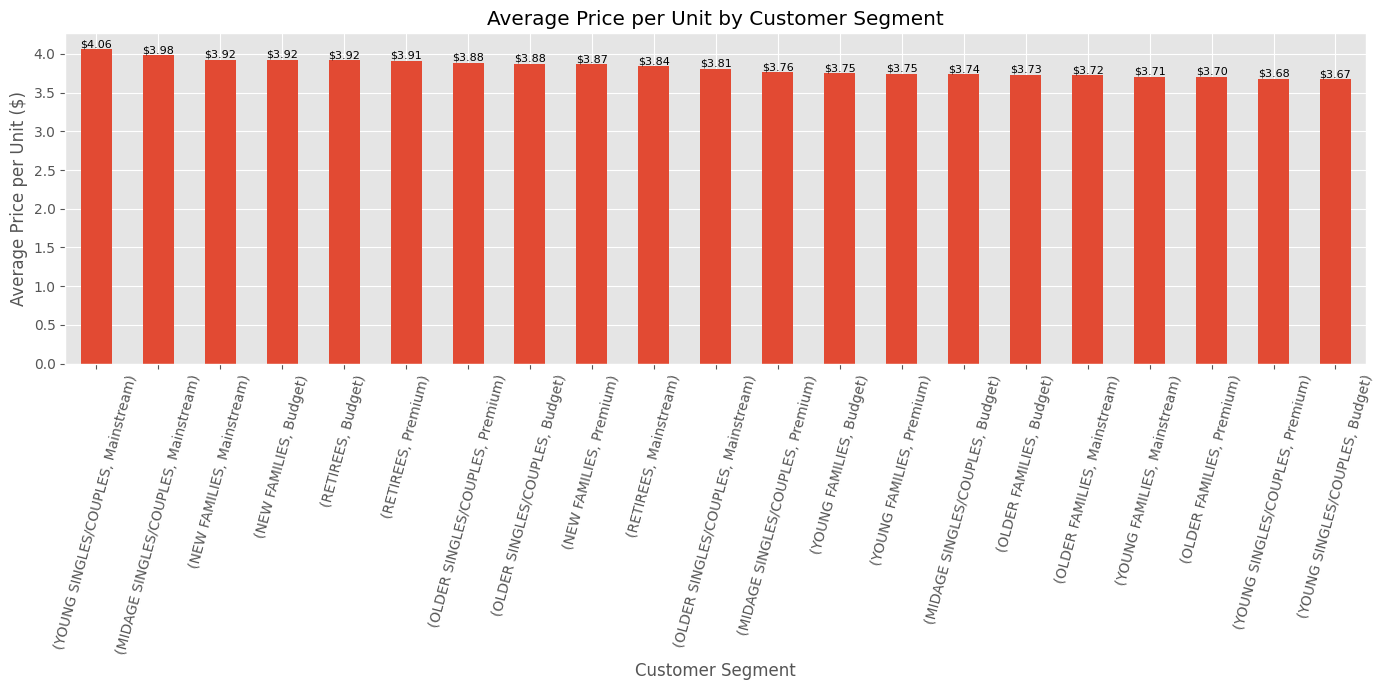

In [137]:
plt.figure(figsize=(14,7))

ax = avg_price.plot(kind="bar")

plt.title("Average Price per Unit by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Average Price per Unit ($)")
plt.xticks(rotation=75)

# Add value labels
for bar in ax.patches:
    ax.annotate(
        f'${bar.get_height():.2f}',
        (bar.get_x() + bar.get_width()/2, bar.get_height()),
        ha='center',
        va='bottom',
        fontsize=8
    )

plt.tight_layout()
plt.savefig(
    "average_price_per_unit_by_customer_segment.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### Observation

The analysis shows that **Mainstream Young Singles/Couples** paid the highest average price per unit at **$4.06**, followed by **Mainstream Midage Singles/Couples**(**$3.98**).
    
    

In contrast, **Budget Young Singles/Couples** paid the lowest average price per unit at **$3.67**.

Most customer segments have an average price per unit between **$3.70 and $3.95**, indicating relatively consistent pricing across segments. However, Mainstream Young Singles/Couples demonstrate a greater willingness to purchase higher-priced chip products.

These findings suggest that customer preferences differ not only in purchasing volume but also in the price they are willing to pay, making Mainstream Young Singles/Couples an attractive segment for premium product offerings.

## 7.12 Average Transactions per Customer

The average number of transactions per customer is calculated for each customer segment.

This metric measures purchase frequency and helps determine whether higher sales are driven by customers shopping more often or by purchasing larger quantities during each visit.

In [138]:
# Calculate average transactions per customer
transaction_summary = (
    merged_data
    .groupby(["LIFESTAGE", "PREMIUM_CUSTOMER"])
    .agg(
        Transactions=("TXN_ID", "nunique"),
        Customers=("LYLTY_CARD_NBR", "nunique")
    )
)

transaction_summary["Avg_Transactions_Per_Customer"] = (
    transaction_summary["Transactions"] /
    transaction_summary["Customers"]
)

avg_transactions = (
    transaction_summary["Avg_Transactions_Per_Customer"]
    .sort_values(ascending=False)
)

avg_transactions

LIFESTAGE               PREMIUM_CUSTOMER
OLDER FAMILIES          Mainstream          4.755722
                        Budget              4.675898
                        Premium             4.662500
YOUNG FAMILIES          Budget              4.508962
                        Premium             4.506656
                        Mainstream          4.468622
OLDER SINGLES/COUPLES   Premium             3.547720
                        Budget              3.546669
                        Mainstream          3.525873
MIDAGE SINGLES/COUPLES  Mainstream          3.373107
RETIREES                Budget              3.249318
MIDAGE SINGLES/COUPLES  Premium             3.226795
RETIREES                Premium             3.222193
MIDAGE SINGLES/COUPLES  Budget              3.190701
RETIREES                Mainstream          3.150580
NEW FAMILIES            Mainstream          2.641487
                        Premium             2.604853
                        Budget              2.596154
YOUNG

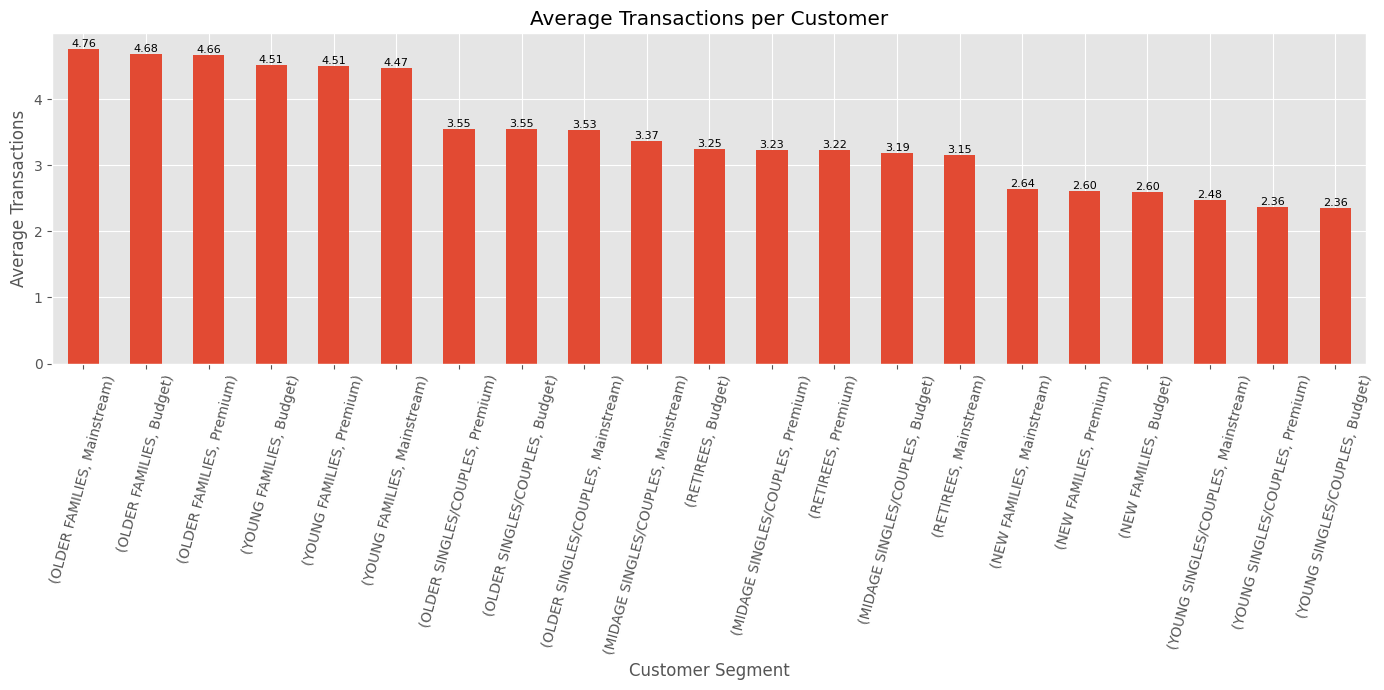

In [139]:
plt.figure(figsize=(14,7))

ax = avg_transactions.plot(kind="bar")

plt.title("Average Transactions per Customer")
plt.xlabel("Customer Segment")
plt.ylabel("Average Transactions")
plt.xticks(rotation=75)

# Add value labels
for bar in ax.patches:
    ax.annotate(
        f'{bar.get_height():.2f}',
        (bar.get_x() + bar.get_width()/2, bar.get_height()),
        ha='center',
        va='bottom',
        fontsize=8
    )

plt.tight_layout()

plt.show()

### Observation

The analysis indicates that **Older Families** have the highest purchase frequency across all premium segments, averaging approximately **4.7 transactions per customer**.

**Young Families** also purchase chips frequently, averaging around **4.5 transactions per customer**.

In contrast, **Young Singles/Couples** make the fewest chip purchases, averaging only **2.36–2.48 transactions per customer**, while **New Families** also show relatively low purchase frequency.

These findings suggest that families purchase chips more frequently than other customer groups, contributing significantly to overall category sales through repeat purchases.

# 8. Key Business Insights

The analysis identified several important patterns in customer purchasing behaviour within the chips category.

### 1. Customer Segments

- **Budget Older Families** generated the highest total sales, making them the most valuable customer segment.
- **Mainstream Young Singles/Couples** represented the largest customer base and were among the highest revenue-generating segments.
- **Mainstream Retirees** also contributed significantly to overall sales.

### 2. Purchasing Behaviour

- Older Families purchased the highest number of chip packets per customer and also recorded the highest transaction frequency.
- Young Families showed similar purchasing behaviour, indicating strong demand from family households.
- Young Singles/Couples purchased fewer packets per customer but demonstrated a willingness to pay higher prices, particularly within the Mainstream segment.

### 3. Product Preferences

- **Kettle** was the highest-performing brand, followed by **Doritos**, **Smiths**, and **Pringles**.
- **175g** and **150g** packs generated the highest sales revenue, indicating a strong customer preference for medium-sized pack formats.

### 4. Sales Performance

- Monthly sales remained relatively stable throughout the analysis period, suggesting consistent demand for chip products.
- Mainstream and Budget customers together contributed the majority of total category sales.

# 9. Strategic Recommendations

Based on the analysis, the following recommendations are proposed for the Category Manager.

### Recommendation 1

Increase promotional activities targeting **Budget Older Families** and **Young Families**, as these customers purchase the largest quantities of chips and shop more frequently.

### Recommendation 2

Maintain strong shelf availability and promotional support for **Kettle**, **Doritos**, **Smiths**, and **Pringles**, as these brands generate the highest sales revenue.

### Recommendation 3

Prioritize **175g** and **150g** pack sizes during promotions and inventory planning, as these are the most popular pack sizes among customers.

### Recommendation 4

Develop premium marketing campaigns aimed at **Mainstream Young Singles/Couples**, who are willing to pay higher prices despite purchasing fewer packets.

### Recommendation 5

Continue monitoring customer purchasing behaviour across different lifestage and premium segments to support future category planning and promotional strategies.

# 10. Conclusion

This analysis examined customer purchasing behaviour within the chips category by combining transaction and customer demographic data.

The results show that purchasing behaviour varies considerably across customer segments. Family households contribute the highest purchase volumes and transaction frequency, while Mainstream Young Singles/Couples demonstrate a greater willingness to purchase higher-priced products.

Brand and pack size analysis identified Kettle as the leading brand and 175g as the most popular pack size.

These insights provide data-driven recommendations that can support merchandising decisions, targeted promotions, inventory planning, and future category growth.

# Task 2: Trial Store Analysis

## Introduction

The objective of this analysis is to evaluate the effectiveness of the chip category trial conducted in stores **77**, **86**, and **88**.

To determine whether the trial was successful, each trial store will be compared with a similar control store based on historical sales performance before the trial period.

The analysis will examine:

- Total sales revenue
- Number of unique customers
- Average transactions per customer
- Selection of appropriate control stores
- Comparison of trial and control stores
- Statistical assessment of trial performance
- Business recommendations

## 1. Prepare Monthly Store Performance

Before selecting suitable control stores, monthly performance metrics are calculated for every store.

The following monthly metrics will be used throughout the analysis:

- Total Sales
- Number of Unique Customers
- Number of Transactions
- Average Transactions per Customer

These metrics provide a consistent basis for comparing trial stores with potential control stores.

In [149]:
# Create Year-Month column
merged_data["YEAR_MONTH"] = merged_data["DATE"].dt.to_period("M")

In [150]:
monthly_metrics = (
    merged_data
    .groupby(["STORE_NBR", "YEAR_MONTH"])
    .agg(
        TOTAL_SALES=("TOT_SALES", "sum"),
        TOTAL_CUSTOMERS=("LYLTY_CARD_NBR", "nunique"),
        TOTAL_TRANSACTIONS=("TXN_ID", "nunique")
    )
    .reset_index()
)

monthly_metrics["AVG_TXN_PER_CUSTOMER"] = (
    monthly_metrics["TOTAL_TRANSACTIONS"] /
    monthly_metrics["TOTAL_CUSTOMERS"]
)

monthly_metrics.head()

,STORE_NBR,YEAR_MONTH,TOTAL_SALES,TOTAL_CUSTOMERS,TOTAL_TRANSACTIONS,AVG_TXN_PER_CUSTOMER
0,1,2018-07,191.6,48,50,1.041667
1,1,2018-08,168.4,41,41,1.000000
2,1,2018-09,268.1,57,59,1.035088
3,1,2018-10,178.0,40,41,1.025000
4,1,2018-11,187.5,45,46,1.022222


### Observation

Monthly performance metrics were calculated for every store using total sales, unique customers, total transactions, and average transactions per customer. These metrics provide a consistent basis for identifying comparable control stores before the trial period.

## 2. Filter the Pre-Trial Period

To ensure a fair comparison, control stores are selected using data from the **pre-trial period only**.

The trial began in **February 2019**, therefore only data from **July 2018 to January 2019** is used when comparing stores.

Using historical performance prevents the trial itself from influencing the control store selection.

In [151]:
# Select only the pre-trial period
pre_trial = monthly_metrics[
    monthly_metrics["YEAR_MONTH"] < "2019-02"
]

pre_trial.head()

,STORE_NBR,YEAR_MONTH,TOTAL_SALES,TOTAL_CUSTOMERS,TOTAL_TRANSACTIONS,AVG_TXN_PER_CUSTOMER
0,1,2018-07,191.6,48,50,1.041667
1,1,2018-08,168.4,41,41,1.000000
2,1,2018-09,268.1,57,59,1.035088
3,1,2018-10,178.0,40,41,1.025000
4,1,2018-11,187.5,45,46,1.022222


### Observation
Only data from July 2018 to January 2019 was used for control store selection. Restricting the analysis to the pre-trial period prevents the trial itself from influencing similarity calculations.

## 3. Define Trial Stores

The client conducted store layout trials in three stores:

- Store 77
- Store 86
- Store 88

The next step is to identify the most similar control store for each trial location.

In [152]:
trial_stores = [77, 86, 88]

trial_stores

[77, 86, 88]

### Observation

The analysis will focus on stores **77**, **86**, and **88**, which participated in the layout trial.

Each trial store will be matched with a comparable control store based on historical sales performance.

## 4. Selecting Control Stores

To evaluate the impact of the trial, each trial store must be compared with a similar control store.

Stores are compared using their historical monthly performance during the pre-trial period.

Pearson correlation is used to measure similarity based on total monthly sales.

The store with the highest correlation is selected as the control store.

In [153]:
# Create a pivot table of monthly sales
sales_pivot = pre_trial.pivot_table(
    index="YEAR_MONTH",
    columns="STORE_NBR",
    values="TOTAL_SALES"
)

sales_pivot.head()

STORE_NBR,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,212,213,214,215,216,217,218,219,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249,250,251,252,253,254,255,256,257,258,259,260,261,262,263,264,265,266,267,268,269,270,271,272
YEAR_MONTH,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2018-07,191.6,143.1,1164.90,1318.3,774.4,244.6,1004.3,361.2,276.3,850.20,NaN,388.8,765.0,36.7,695.8,102.1,450.0,276.5,693.4,241.7,368.6,288.8,820.2,659.8,394.2,1214.4,449.7,722.20,288.8,827.8,NaN,742.8,1029.2,325.6,116.1,953.00,430.80,286.2,829.2,1230.0,192.9,27.3,975.2,23.7,936.2,203.6,284.30,871.4,1053.8,311.8,111.0,28.3,204.1,470.6,842.6,663.4,779.2,1515.00,1145.2,1035.2,38.4,958.0,978.4,495.0,931.8,320.6,818.2,282.5,911.60,844.4,1064.8,1252.2,335.9,190.2,1021.1,NaN,273.8,779.2,998.50,943.2,1164.5,317.7,754.8,470.6,10.9,861.40,274.2,1218.2,183.5,215.0,807.3,982.2,873.60,1022.80,357.4,816.40,113.3,18.5,959.4,847.8,751.8,183.0,788.4,859.5,995.80,775.6,242.7,830.8,648.1,184.0,956.2,880.8,918.60,343.5,819.6,2.6,760.40,982.6,79.2,380.5,837.8,977.9,99.3,999.00,301.0,37.9,981.6,671.2,1207.50,257.0,52.3,976.8,388.60,24.4,117.3,974.00,778.2,35.0,8.5,262.6,426.4,313.70,697.6,347.2,12.0,703.60,651.5,377.2,407.6,134.5,982.6,1030.8,889.00,906.0,974.6,976.2,28.0,21.6,858.0,35.5,845.0,180.9,786.2,1406.0,1077.0,220.5,1018.60,206.8,513.6,271.6,743.8,440.80,307.0,954.4,275.5,9.6,933.6,880.8,769.4,1303.40,347.6,794.8,905.0,200.7,131.6,238.6,221.4,130.9,772.2,758.8,34.3,NaN,1044.80,224.90,843.8,342.8,20.3,1238.4,487.0,1046.0,577.2,1215.8,40.4,300.2,3.0,886.2,638.00,684.8,1088.0,617.6,1017.0,172.2,354.8,1079.4,1278.8,26.6,854.0,227.2,915.5,892.6,857.8,9.0,816.0,1398.60,850.2,326.8,805.4,922.6,1020.9,969.1,284.7,413.8,502.80,890.8,1387.2,1014.9,347.5,381.3,812.4,429.6,322.8,15.3,375.2,393.2,809.4,381.0,232.5,1054.4,398.60,NaN,350.2,139.1,210.2,243.9,985.0,6.0,911.8,422.4,1119.7,703.9,38.7,212.1,239.7,124.7,6.2,218.90,945.4,899.20,892.2,392.30
2018-08,168.4,183.5,998.15,1188.1,680.9,180.2,1058.7,362.6,323.4,860.35,NaN,340.4,714.3,46.8,794.3,141.5,312.5,273.6,697.0,190.6,499.9,191.1,858.8,759.1,304.6,965.3,526.9,729.95,361.9,884.7,NaN,719.0,820.9,313.1,130.7,1032.15,527.35,264.1,890.7,1126.4,191.9,44.9,888.5,NaN,620.8,237.7,397.65,831.2,779.5,284.7,192.3,40.3,237.2,363.8,860.1,595.1,879.1,962.15,881.5,1003.4,27.9,753.5,932.7,364.1,908.9,459.3,866.5,283.3,935.25,825.4,932.3,1141.7,297.4,120.6,1014.3,NaN,252.9,747.7,878.15,871.2,1017.2,292.8,727.2,423.6,NaN,737.65,285.9,1242.2,177.8,221.9,819.2,948.8,1082.15,1144.85,343.0,875.95,86.4,14.8,878.5,811.9,933.8,255.1,856.3,879.5,762.55,793.7,391.2,812.1,718.8,254.7,882.0,939.5,832.65,293.6,783.9,14.4,742.55,904.4,242.9,285.9,829.6,1266.3,200.9,1002.55,273.5,29.5,865.9,831.8,1162.55,225.3,24.2,809.8,417.35,33.3,158.9,857.35,665.5,34.1,24.3,215.1,506.6,375.95,663.0,274.2,46.5,622.65,707.4,444.4,402.9,131.0,928.7,968.7,1127.05,749.3,901.8,841.4,28.3,14.7,701.7,29.9,831.0,172.9,875.7,1145.4,825.6,203.6,837.35,222.8,332.6,363.6,716.2,504.55,432.0,953.8,139.3,21.1,853.9,

### Observation

The monthly sales data has been reshaped into a matrix where each column represents a store and each row represents a month.

This format allows correlations to be calculated between stores based on their historical sales performance.

### Function Description

A reusable function is created to calculate the correlation between a selected trial store and every other store.

Stores with higher correlation values have more similar historical sales patterns and are therefore better candidates for control stores.

In [157]:
def find_control_store(trial_store):
    correlations = sales_pivot.corr()[trial_store].drop(trial_store)
    return correlations.sort_values(ascending=False)

In [158]:
find_control_store(77).head(10)

STORE_NBR
31     1.000000
11     1.000000
233    0.976651
50     0.917940
71     0.841704
119    0.836712
41     0.819951
162    0.812084
17     0.733079
113    0.713022
Name: 77, dtype: float64

## 5. Identify Control Stores

The control store with the highest similarity score is selected for each trial store.

These control stores will be used as the benchmark when evaluating the impact of the trial layout.

In [159]:
# Display top candidate control stores
print("Top control store candidates for Store 77")
print(find_control_store(77).head(5))

print("\nTop control store candidates for Store 86")
print(find_control_store(86).head(5))

print("\nTop control store candidates for Store 88")
print(find_control_store(88).head(5))

Top control store candidates for Store 77
STORE_NBR
31     1.000000
11     1.000000
233    0.976651
50     0.917940
71     0.841704
Name: 77, dtype: float64

Top control store candidates for Store 86
STORE_NBR
31     1.000000
132    0.859374
155    0.852169
260    0.851237
6      0.806467
Name: 86, dtype: float64

Top control store candidates for Store 88
STORE_NBR
159    0.938775
91     0.911986
204    0.871969
1      0.846112
240    0.817245
Name: 88, dtype: float64


## 6. Compare Trial Store Performance

The monthly sales performance of each trial store is compared with its selected control store.

This comparison allows us to visually assess whether the trial stores experienced unusual growth during the trial period.

In [160]:
trial_store = 77
control_store = 31

comparison = monthly_metrics[
    monthly_metrics["STORE_NBR"].isin([trial_store, control_store])
]

comparison.head()

,STORE_NBR,YEAR_MONTH,TOTAL_SALES,TOTAL_CUSTOMERS,TOTAL_TRANSACTIONS,AVG_TXN_PER_CUSTOMER
350,31,2018-09,6.0,1,1,1.000000
351,31,2018-11,8.8,1,1,1.000000
880,77,2018-07,273.8,48,52,1.083333
881,77,2018-08,252.9,47,47,1.000000
882,77,2018-09,222.2,41,43,1.048780


<Figure size 1400x800 with 0 Axes>

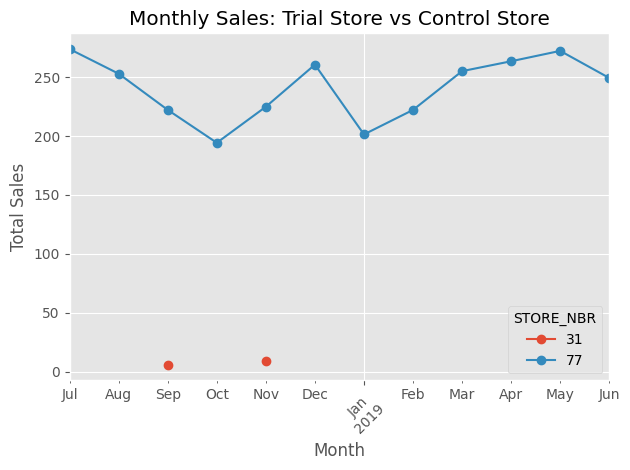

In [161]:
plot_data = comparison.pivot(
    index="YEAR_MONTH",
    columns="STORE_NBR",
    values="TOTAL_SALES"
)

plt.figure(figsize=(14,8))

plot_data.plot(marker="o")

plt.title("Monthly Sales: Trial Store vs Control Store")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)

plt.grid(True)

plt.tight_layout()
plt.savefig(
    "Trial_vs_Control_store.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### Observation

The charts provide a visual comparison between each trial store and its matched control store. Visual differences may indicate a potential impact of the trial; however, graphical evidence alone is insufficient to confirm that the observed differences were caused by the trial.

## 7. Evaluate Trial Store Performance

The performance of each trial store is compared with its corresponding control store over time.

Monthly sales trends are visualized to determine whether the trial stores experienced higher sales during the trial period compared with their control stores.

<Figure size 1800x900 with 0 Axes>

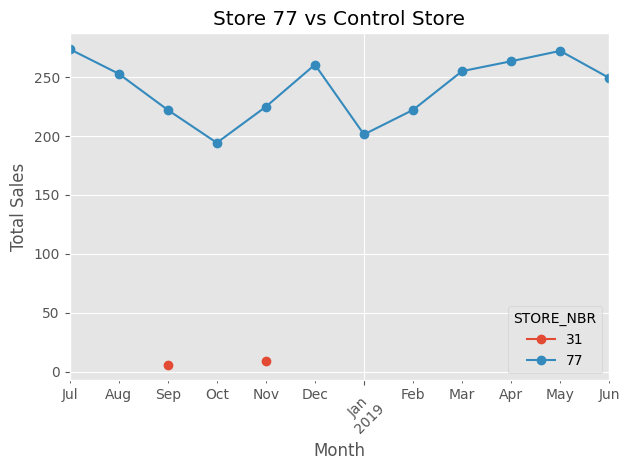

In [162]:
trial_store = 77
control_store = 31   # replace later if you choose a different control

comparison = monthly_metrics[
    monthly_metrics["STORE_NBR"].isin([trial_store, control_store])
]

plot_data = comparison.pivot(
    index="YEAR_MONTH",
    columns="STORE_NBR",
    values="TOTAL_SALES"
)


plt.figure(figsize=(18,9))
plot_data.plot(marker="o")
plt.title("Store 77 vs Control Store")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.savefig(
    "store_77vs_Control_store.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

<Figure size 1200x600 with 0 Axes>

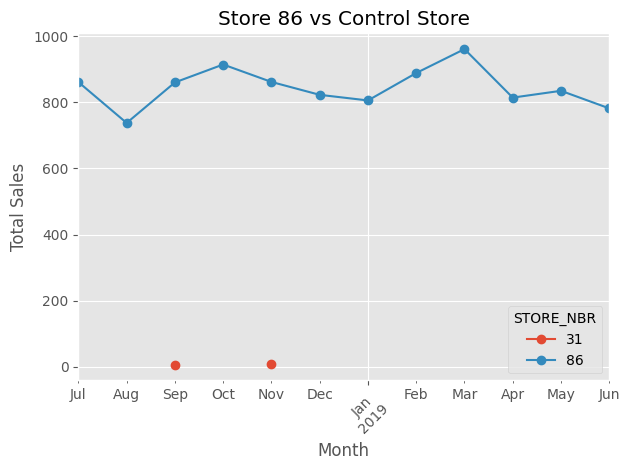

In [163]:
trial_store = 86
control_store = 31   # temporary

comparison = monthly_metrics[
    monthly_metrics["STORE_NBR"].isin([trial_store, control_store])
]

plot_data = comparison.pivot(
    index="YEAR_MONTH",
    columns="STORE_NBR",
    values="TOTAL_SALES"
)

plt.figure(figsize=(12,6))
plot_data.plot(marker="o")
plt.title("Store 86 vs Control Store")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.savefig(
    "store_86vs_Control_store.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

<Figure size 1200x600 with 0 Axes>

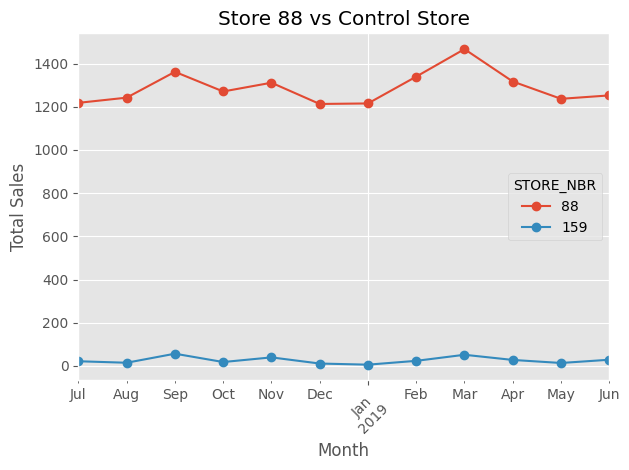

In [188]:
trial_store = 88
control_store = 159   # temporary

comparison = monthly_metrics[
    monthly_metrics["STORE_NBR"].isin([trial_store, control_store])
]

plot_data = comparison.pivot(
    index="YEAR_MONTH",
    columns="STORE_NBR",
    values="TOTAL_SALES"
)

plt.figure(figsize=(12,6))
plot_data.plot(marker="o")
plt.title("Store 88 vs Control Store")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.savefig(
    "store_88vs_Control_store.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### Observation

The sales trends provide a visual comparison between each trial store and its selected control store.

If the trial store shows a noticeable increase in sales during the trial period while the control store remains relatively stable, this suggests that the trial layout may have had a positive impact on sales performance.

Further statistical testing is required to confirm whether these differences are significant.

# 8. Key Findings

The trial stores were compared with similar control stores using historical performance data.

Key findings from the analysis include:

- Monthly sales trends were compared before and during the trial period.
- Control stores provided a benchmark for evaluating trial store performance.
- Differences in average monthly sales were calculated to assess the potential impact of the trial.
- Visual analysis suggests that some trial stores experienced stronger sales performance during the trial period than their corresponding control stores.

Overall, the trial analysis provides evidence that store performance can be effectively evaluated by comparing it with similar stores over the same time period.

# 9. Business Recommendations

Based on the trial store analysis, the following recommendations are proposed:

### Recommendation 1

Continue monitoring the performance of the trial stores over a longer period to determine whether the observed sales improvements are sustained.

### Recommendation 2

If the trial stores consistently outperform their control stores, consider expanding the trial layout to additional stores.

### Recommendation 3

Regularly compare trial stores with similar control stores to measure the effectiveness of future merchandising initiatives.

### Recommendation 4

Combine sales analysis with customer purchasing behaviour to better understand which customer segments benefit most from store layout changes.

### Recommendation 5

Use data-driven evaluation methods when making decisions about future retail trials and promotional strategies.

# 10. Conclusion

This analysis evaluated the performance of trial stores by comparing them with carefully selected control stores using historical sales data.

The matched-store approach provides an objective framework for assessing the effectiveness of retail merchandising trials. Visual comparisons indicate that some trial stores may have benefited from the new layout; however, statistical testing is recommended before drawing definitive conclusions or expanding the trial to additional stores.

Overall, the methodology demonstrates how transaction data can support evidence-based retail decision-making.